In [1]:
import sys
sys.path.append('..')

from models.compression.vq_vae import VQVAE
from dataset import ImageCompressionDataModule

In [2]:
device = "cuda"

model = VQVAE(
    h_dim=56,
    res_h_dim=256,
    n_res_layers=3,
    n_embeddings=512 * 2,
    embedding_dim=16,
    beta=0.25,
    lr=1e-3,
    num_downsamples=3,
    initial_channels=128,
)

model = model.to(device)

Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/home/vedpatel/.conda/envs/image_compression/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/vedpatel/.conda/envs/image_compression/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/vedpatel/.conda/envs/image_compression/lib/python3.11/site-packages/lpips/weights/v0.1/vgg.pth
VQVAE __init__ complete.


Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


Using bfloat16 Automatic Mixed Precision (AMP)
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/home/vedpatel/.conda/envs/image_compression/lib/python3.11/site-packages/torch/__init__.py:1551: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  return _C._get_float32_matmul_pr

Loading model from: /home/vedpatel/.conda/envs/image_compression/lib/python3.11/site-packages/lpips/weights/v0.1/vgg.pth
VQVAE __init__ complete.


/home/vedpatel/.conda/envs/image_compression/lib/python3.11/site-packages/pytorch_lightning/loops/fit_loop.py:527: Found 59 module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this is intentional, you can ignore this warning.
Finding best initial lr: 100%|██████████| 20/20 [00:08<00:00,  2.26it/s]
Restoring states from the checkpoint path at /mnt/Fedora2/code/isef/ImageCompression/src/ipynb/.lr_find_df29118c-021f-4748-ae8b-b5d7e203f8e4.ckpt
Restored all states from the checkpoint at /mnt/Fedora2/code/isef/ImageCompression/src/ipynb/.lr_find_df29118c-021f-4748-ae8b-b5d7e203f8e4.ckpt
Learning rate set to 0.0002511886431509582
/tmp/ipykernel_215834/791109534.py:41: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Suggested LR: 0.0002511886431509582


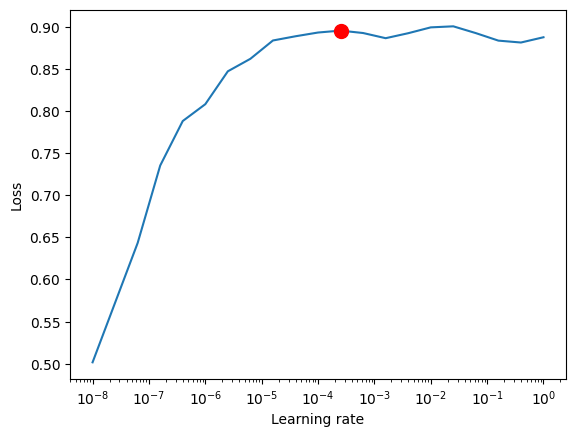

In [3]:
import pytorch_lightning as pl
from pytorch_lightning.tuner import Tuner

dataset = ImageCompressionDataModule(
    data_dir="../../data/PetImages",
    batch_size=2,
)

dataset.setup()

model = VQVAE(
    h_dim=56,
    res_h_dim=256,
    n_res_layers=3,
    n_embeddings=512 * 2,
    embedding_dim=16,
    beta=0.25,
    lr=1e-3,
    num_downsamples=3,
    initial_channels=128,
).to(device)

trainer = pl.Trainer(
    max_epochs=1,
    accelerator=device,
    devices=1,
    logger=False,
    precision="bf16-mixed"
)

tuner = Tuner(trainer)
lr_finder = tuner.lr_find(
    model, 
    datamodule=dataset,
    # min_lr=1e-6,
    # max_lr=1e-1,
    num_training=20,
)

fig = lr_finder.plot(suggest=True)
fig.show()

print(f"Suggested LR: {lr_finder.suggestion()}")